## Enunciado del ejercicio
Este ejercicio consiste en predecir el costo de un incidente de seguridad en vase al numero que se han visto afectados. Es congunto de datos es generado de manera aleatoria.

# Realizar importanciones


## Instalaciones de librerias externas
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn


In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -----------------------------

# Generacion del conjunto de datos

In [5]:
import numpy as np

x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.rand(100,1)
print("La longitud del conjunto de datos:",len(x))


La longitud del conjunto de datos: 100


### Visualizacion del conjunto de datos

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline


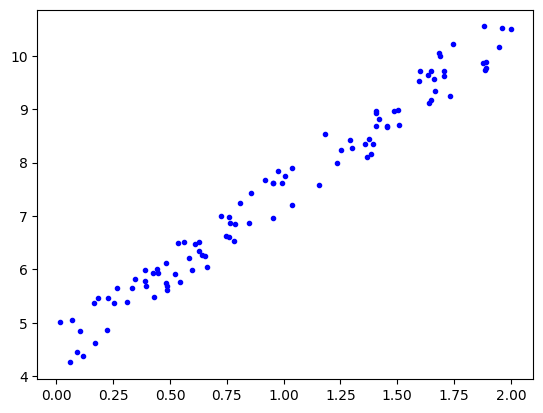

In [8]:
plt.plot(x,y,"b.")
plt.show()

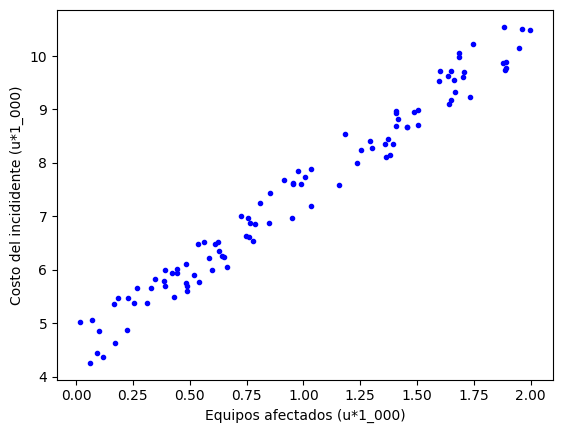

In [11]:
plt.plot(x,y,"b.")
plt.xlabel("Equipos afectados (u*1_000)")
plt.ylabel("Costo del incididente (u*1_000)")
plt.show()

### Modificacion del conjunto de datos

In [12]:
import pandas as pd

convertimos los datos a su valor real, en lugar de usar factores de conversion

In [13]:
data = {'n_equipos_afectados': x.flatten(),'costo': y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,costo
0,0.183984,5.465146
1,1.732912,9.240231
2,0.061828,4.257683
3,1.417708,8.816095
4,1.365169,8.106709
5,0.652086,6.245852
6,0.537267,6.488032
7,1.641579,9.109231
8,1.667326,9.332001
9,0.952365,6.967715


# Escalado del numero de equipos afectados a un valor mas real

In [14]:
df['n_equipos_afectados']= df['n_equipos_afectados'] * 1_000
df['n_equipos_afectados']= df['n_equipos_afectados'].astype('int')

# Escalado del costo a un valor mas real

In [15]:
df['costo']= df['costo'] * 10_000
df['costo']= df['costo'].astype('int')

df.head(10)

,n_equipos_afectados,costo
0,183,54651
1,1732,92402
2,61,42576
3,1417,88160
4,1365,81067
5,652,62458
6,537,64880
7,1641,91092
8,1667,93320
9,952,69677


# Representacion grafica del conjunto de datos

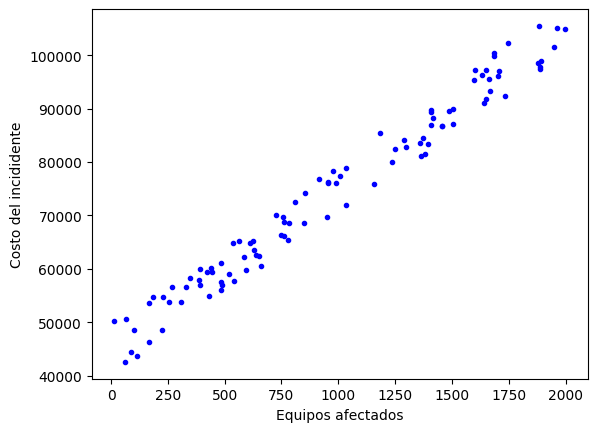

In [16]:
plt.plot(df['n_equipos_afectados'],df['costo'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incididente")
plt.show()

# Construccion del modelo

In [17]:
!pip install scikit-learn

In [18]:
from sklearn.linear_model import LinearRegression

Carga de modelo y ajuste de la funcion Hipotesis

In [19]:
lin_rege = LinearRegression()
lin_rege.fit(df['n_equipos_afectados'].values.reshape(-1,1) ,df['costo'].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Muestra el valor que se le asigno al parametro Theta0 (Lugar donde corta el modelo con el eje "Y"

In [20]:
lin_rege.intercept_

np.float64(45441.24856331597)

muestra el Vaor que se le asigno al parametro Theta1 (pendiente que tendra el modelo de regresion lineal)

In [21]:
lin_rege.coef_

array([29.57990926])

### Prediccion para el valor minimo y maximo del conjunto de datos de entrenaiento

In [22]:
x_min_max = np.array([[df['n_equipos_afectados'].min()],[df['n_equipos_afectados'].max()]])
y_train_pred = lin_rege.predict(x_min_max)

# Representacion Grafica de la funcion de Hipotesis Generada

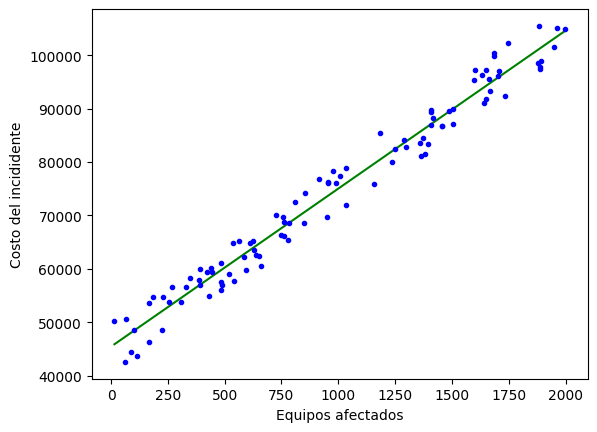

In [23]:
plt.plot(x_min_max,y_train_pred,"g-")
plt.plot(df['n_equipos_afectados'],df['costo'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incididente")
plt.show()

### Prediccion de nuevos ejemplos

In [27]:
x_new = np.array([760]) # 760 equipos afectados

Prediccion del costo que tendria este incidente

In [28]:
costo = lin_rege.predict(x_new)
print("El costo del incididente seria: ",costo)

ValueError: Expected 2D array, got 1D array instead:
array=[760].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
plt.plot(x_min_max,y_train_pred,"g-")
plt.plot(df['n_equipos_afectados'],df['costo'], "b.")
plt.plot(x_new,costo,"rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incididente")
plt.show()